# Paper-Tiger — a quantitative teardown 🔬
### Faithful replication · both Sharpe conventions · the spanning-alpha test · post-publication decay · portfolio test

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Beats the market?: Not supported](https://img.shields.io/badge/Beats_the_market%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We replicate Antonacci's Global Equities Momentum on real ETFs and ask whether the vendor's headline survives a fair benchmark, honest inference, and a portfolio context — and, crucially, whether the *switching* itself carries any alpha once you regress the book on its own ingredients.

> ⚠️ **Not investment advice.** Monthly total-return SPY/EFA/AGG + ^IRX (Yahoo), 2003–2026, 20 bp/switch. Inference via `quantlab.analytics` (Lo 2002, Newey-West 1987). Sources in [`docs/references.md`](../docs/references.md).
>
> 💡 **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (paper_tiger/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from paper_tiger import data, strategy as st

prices, tbill = data.fetch_etfs()          # cache-first; built by examples/verify.py --fetch
gem  = st.gem_returns(prices, tbill, cost_bps=20.0)
gem0 = st.gem_returns(prices, tbill, cost_bps=0.0)
spy  = st.buy_and_hold(prices, "US").loc[gem.index]
b40  = st.blend(prices).loc[gem.index]
rf   = tbill.reindex(gem.index)            # the cash leg — Sharpe is quoted raw AND excess of this
def curve(s): return (1+s).cumprod()
from quantlab.analytics import sharpe_with_se, mean_tstat_hac


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| Signal | **Weak** | spanning alpha on SPY/AGG: +10 bp/mo, HAC t **0.49** — the raw t≈3.5 belongs to the assets |
| Tradability | **Fragile** | edge = crash protection only; one crisis; decays; no real portfolio-Sharpe lift |
| Beats the market? | **Not supported** | trails SPY raw (0.76 vs 0.79) and excess (0.62 vs 0.67); loses to 60/40 (0.87 / 0.68) |

> 💡 *In plain words:* it's a real return stream, but the part that's statistically solid is the equity-and-bond premium it carries — the timing decision itself adds nothing you can distinguish from zero.

## 1 · The claim, steelmanned

- **H₁ (signal):** the *switching* adds value — GEM's alpha over a fixed mix of its own ingredients (SPY/AGG) is positive under autocorrelation-robust inference.
- **H₂ (the pitch):** GEM beats buy-and-hold *and* a naïve 60/40 on Sharpe (any convention).
- **H₃ (the real value):** GEM's edge is decorrelated crash protection that improves a portfolio.

## 2 · So what? — what rides on each answer

If H₂ holds, dual momentum is a free lunch and every 60/40 investor is leaving Sharpe on the table. If only a weak H₃ holds, it's a defensive overlay whose marketing oversells it — useful to know before anchoring on a backtest. And H₁ is the trap this study exists to spring: a t-stat on the raw mean of an always-invested book *cannot* test the strategy, because holding anything with a premium passes it.

## 3 · How we'd know — the protocol

Replicate faithfully → benchmark against SPY and 60/40 in **both Sharpe conventions** (raw and excess of ^IRX) → the **spanning regression** of GEM's excess return on its ingredients' excess returns, HAC t on the intercept (the timing alpha) → Lo (2002) / Newey-West book-level inference for the record → split the sample pre/post-publication for decay → decompose returns in the worst-decile equity months → test a 30% GEM sleeve in a 60/40.

## 4 · The teardown

### 4.1 GEM vs the benchmarks that matter — raw and excess of cash

A raw Sharpe on an always-invested book silently pockets the cash rate. The excess-of-cash convention is what Lo's t-stat actually speaks, and with 2023–26 bills near 5% the difference is material. Both, side by side:

In [2]:
names = {'GEM gross': gem0, 'GEM net (20bp)': gem, 'Buy & Hold SPY': spy, '60/40 SPY/AGG': b40}
tbl = pd.DataFrame({nm: {'sharpe_raw': st.summary(x)['sharpe'],
                         'sharpe_excess': st.summary(x, rf=rf)['sharpe'],
                         'cagr': st.summary(x)['cagr'], 'vol_ann': st.summary(x)['vol_ann'],
                         'max_drawdown': st.summary(x)['max_drawdown'], 'skew': st.summary(x)['skew']}
                    for nm, x in names.items()}).T
display(tbl.round(3))
print('excess Sharpe: GEM net %.2f  |  SPY %.2f  |  60/40 %.2f' % (
    st.summary(gem, rf=rf)['sharpe'], st.summary(spy, rf=rf)['sharpe'], st.summary(b40, rf=rf)['sharpe']))

,sharpe_raw,sharpe_excess,cagr,vol_ann,max_drawdown,skew
GEM gross,0.787,0.641,0.094,0.125,-0.225,-0.402
GEM net (20bp),0.761,0.615,0.091,0.125,-0.233,-0.397
Buy & Hold SPY,0.789,0.667,0.113,0.150,-0.508,-0.513
60/40 SPY/AGG,0.871,0.680,0.082,0.096,-0.323,-0.556


excess Sharpe: GEM net 0.62  |  SPY 0.67  |  60/40 0.68


> 💡 *In plain words:* in **both** conventions GEM trails SPY and loses to the lazy 60/40. **H₂ is dead on arrival** — there is no benchmark under which the headline survives.

### 4.2 Is the *signal* real? The spanning test

Regress GEM's excess return on the excess returns of its own doors:
$$r_{GEM} - r_f = \alpha + \beta_1 (r_{SPY} - r_f) + \beta_2 (r_{AGG} - r_f) + \varepsilon$$
The intercept is the return the *switching* added that a fixed mix of the same ETFs could not have earned — the only number that measures dual-momentum skill. HAC (Newey-West) errors.

In [3]:
rets = st.to_returns(prices)
fac = pd.DataFrame({'SPY': rets['US'], 'AGG': rets['BOND']}).sub(tbill, axis=0).loc[gem.index]
sp = st.spanning_alpha((gem - rf).dropna(), fac)
print(f"alpha {sp['alpha_bps_m']:.0f} bp/mo ({sp['alpha_ann_pct']:.1f}%/yr)  HAC t={sp['tstat']:.2f}  "
      f"betas SPY {sp['betas']['SPY']:.2f} / AGG {sp['betas']['AGG']:.2f}  R2={sp['r2']:.2f}  (n={sp['n']})")
sp40 = st.spanning_alpha((gem - rf).dropna(), (b40 - rf).dropna().rename('60/40').to_frame())
print(f"vs the 60/40 directly: alpha {sp40['alpha_bps_m']:.0f} bp/mo  HAC t={sp40['tstat']:.2f}  beta {sp40['betas']['60/40']:.2f}")

alpha 10 bp/mo (1.2%/yr)  HAC t=0.49  betas SPY 0.64 / AGG 0.08  R2=0.60  (n=260)
vs the 60/40 directly: alpha 10 bp/mo  HAC t=0.48  beta 0.99


> 💡 *In plain words:* **t ≈ 0.5.** The timing alpha is statistically indistinguishable from zero. **H₁ fails** — and this is the test that the seductive "t = 3.5 on the mean" was standing in for.

### 4.3 …then what was the t = 3.5 measuring? The asset premium

For the record, the book-level inference in both conventions — and the same test applied to plain SPY, which 'passes' it too:

In [4]:
ex = (gem - rf).dropna()
lo_x, hac_x = sharpe_with_se(gem, periods_per_year=12, rf=rf), mean_tstat_hac(ex)
lo_r, hac_r = sharpe_with_se(gem, periods_per_year=12), mean_tstat_hac(gem)
spy_x = sharpe_with_se(spy, periods_per_year=12, rf=rf)
print(f"GEM excess-of-cash: Lo Sharpe {lo_x['sharpe_ann']:.2f} t={lo_x['tstat']:.2f} | HAC mean {hac_x['mean_bps']:.0f} bp/mo t={hac_x['tstat']:.2f}")
print(f"GEM raw:            Lo Sharpe {lo_r['sharpe_ann']:.2f} t={lo_r['tstat']:.2f} | HAC mean {hac_r['mean_bps']:.0f} bp/mo t={hac_r['tstat']:.2f}")
print(f"SPY excess-of-cash: Lo Sharpe {spy_x['sharpe_ann']:.2f} t={spy_x['tstat']:.2f}  <- buy-and-hold passes the same bar")

GEM excess-of-cash: Lo Sharpe 0.62 t=2.84 | HAC mean 64 bp/mo t=2.94
GEM raw:            Lo Sharpe 0.76 t=3.50 | HAC mean 79 bp/mo t=3.61
SPY excess-of-cash: Lo Sharpe 0.67 t=3.08  <- buy-and-hold passes the same bar


> 💡 *In plain words:* yes, GEM's mean clears t = 2 — but so does just owning SPY, with a *higher* excess Sharpe. A significance test that a do-nothing benchmark passes can't certify a strategy. The signal stamp is **Weak**: real return stream, no demonstrable timing skill.

### 4.4 What's real: crash protection (worst-decile SPY months)

,GEM,SPY
worst-decile SPY months,-4.970,-7.740
the rest,1.430,1.960


n crisis months = 26 | corr GEM~SPY in crises = -0.01


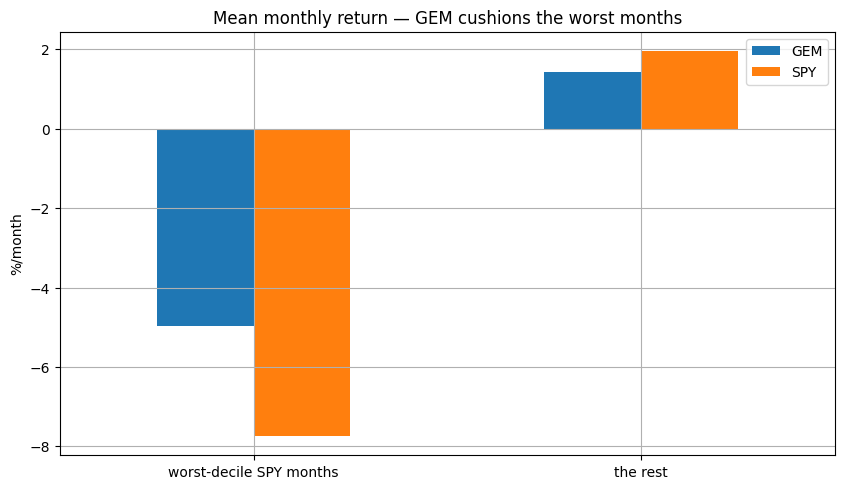

In [5]:
crisis = spy <= spy.quantile(0.10)
comp = pd.DataFrame({'GEM': [gem[crisis].mean()*100, gem[~crisis].mean()*100],
                     'SPY': [spy[crisis].mean()*100, spy[~crisis].mean()*100]},
                    index=['worst-decile SPY months','the rest'])
display(comp.round(2))
print('n crisis months =', int(crisis.sum()), '| corr GEM~SPY in crises = %.2f' % gem[crisis].corr(spy[crisis]))
ax = comp.plot.bar(rot=0, title='Mean monthly return — GEM cushions the worst months'); ax.set_ylabel('%/month'); plt.show()

> 💡 *In plain words:* in the months that hurt, GEM loses ~2.8 pts/month less than SPY and is uncorrelated to it (it's in bonds). **H₃'s cushion is real** — now, is it *fragile*?

### 4.5 Why it's fragile: post-publication decay

,2004–2013,2014–2026
raw,0.870,0.680
excess,0.740,0.520


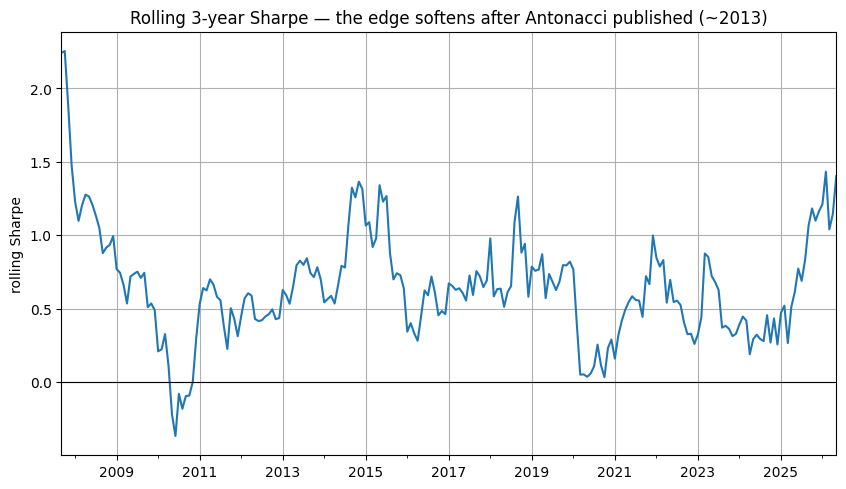

In [6]:
sub = pd.DataFrame({'2004–2013': {'raw': st.summary(gem.loc['2004':'2013'])['sharpe'],
                                  'excess': st.summary(gem.loc['2004':'2013'], rf=rf)['sharpe']},
                    '2014–2026': {'raw': st.summary(gem.loc['2014':'2026'])['sharpe'],
                                  'excess': st.summary(gem.loc['2014':'2026'], rf=rf)['sharpe']}})
display(sub.round(2))
from quantlab.analytics import rolling_sharpe
rs = rolling_sharpe(gem, window=36, periods_per_year=12)
ax = rs.plot(title='Rolling 3-year Sharpe — the edge softens after Antonacci published (~2013)')
ax.axhline(0, color='k', lw=.8); ax.set_ylabel('rolling Sharpe'); plt.show()

> 💡 *In plain words:* excess Sharpe 0.74 → 0.52 across the publication line — the textbook McLean–Pontiff fade. The cushion also leans heavily on **one** crisis (2008), so the independent-observation count behind the 23-year chart is thin.

### 4.6 The portfolio test: does a GEM sleeve help a 60/40?

In [7]:
mix = 0.7*b40 + 0.3*gem
port = pd.DataFrame({'60/40 only': {'sharpe_excess': st.summary(b40, rf=rf)['sharpe'],
                                    'max_drawdown': st.summary(b40)['max_drawdown']},
                     '70% 60/40 + 30% GEM': {'sharpe_excess': st.summary(mix, rf=rf)['sharpe'],
                                             'max_drawdown': st.summary(mix)['max_drawdown']}}).T
display(port.round(3))
print('excess Sharpe %.2f -> %.2f ; maxDD %.0f%% -> %.0f%% (trimmed)' % (
    st.summary(b40, rf=rf)['sharpe'], st.summary(mix, rf=rf)['sharpe'],
    100*st.summary(b40)['max_drawdown'], 100*st.summary(mix)['max_drawdown']))

,sharpe_excess,max_drawdown
60/40 only,0.680,-0.323
70% 60/40 + 30% GEM,0.695,-0.266


excess Sharpe 0.68 -> 0.70 ; maxDD -32% -> -27% (trimmed)


> 💡 *In plain words:* the sleeve trims drawdown (−32% → −27%) and nudges the excess Sharpe 0.68 → 0.70 — a rounding-error lift, consistent with a zero-alpha sleeve that's merely defensive. Compare Study 31's trend sleeve, which lifts a 60/40 0.48 → 0.56 — that's what genuinely decorrelated alpha looks like. **H₃ is real but thin.**

## 5 · The verdict

H₁ **fails** (spanning alpha t ≈ 0.5 — the raw t ≈ 3.5 belongs to the asset premium). H₂ **rejected** (trails SPY, loses to 60/40, both conventions). H₃ **weakly holds** (real cushion, but one crisis, decaying, no meaningful Sharpe lift). → Signal `WEAK`, Tradability `FRAGILE`, market-beating claim `NOT SUPPORTED`.

## 6 · Could you trade it?

Easily — ~1.5 switches/year, 20 bp barely registers (gross 0.79 → net 0.76 raw), no capacity issue on SPY/EFA/AGG. The constraint isn't tradability; it's that the fair benchmark (60/40) already wins, so the strategy has to justify itself purely as drawdown insurance — and a cheaper insurance (just hold more bonds) does much the same.

## 7 · Going further

Forks: (a) substitute VEU/IEFA for EFA and BND for AGG — does the thin edge survive the proxy choice? (b) bootstrap the spanning alpha's distribution rather than relying on the HAC asymptotics; (c) re-run on a point-in-time membership to kill any residual survivorship in the equity proxies. The backlog of vendor strategies to mirror this way is in [`docs/pwb_strategies_inventory.md`](../../../docs/pwb_strategies_inventory.md).